# Brisk-light mode

This notebook illustrates how to use the **brisk-light** mode of AART, which was developed by Daniel Rojas-Paternina. This prescription accounts for the distribution of Kerr null-geodesic travel times across the observer screen, allowing black-hole movie frames to retain the propagation-induced time-delay structure associated with different lensing bands. 

In [1]:
from aart_func import *
from params import * # The file params.py contains all the relevant parameters for the simulations


Thanks for using AART


## Lensing band computation

The lensing bands are computed according to the parameters defined in `params.py`, which contains the full configuration required to run AART.

In [2]:
%time !python lensingbands.py


Thanks for using AART
Computing the lensing bands
Number of points in the n=0 grid  6250000
Number of points in the n=1 grid  6250000
Number of points in the n=2 grid  6250000
File  ./Results/LensingBands_a_0.94_i_17.h5  created.
CPU times: user 109 ms, sys: 50.1 ms, total: 159 ms
Wall time: 23.1 s


Here we extract the relevant information from the computed lensing band.

In [3]:
#path_lb = "path where the lensing bands file was created"
fnbands="./Results/LensingBands_a_%s_i_%s.h5"%(spin_case,i_case)

print("Reading file: ",fnbands)

h5f = h5py.File(fnbands,'r')

#Points for the boundary of the BH shadow
alpha_critc=h5f['alpha'][:]
beta_critc=h5f['beta'][:]

#The concave hulls for the lensing bands
hull_0i=h5f['hull_0i'][:]
hull_0e=h5f['hull_0e'][:]
hull_1i=h5f['hull_1i'][:]
hull_1e=h5f['hull_1e'][:]
hull_2i=h5f['hull_2i'][:]
hull_2e=h5f['hull_2e'][:]

#The grid points for each lensing band
supergrid0=h5f['grid0'][:]
N0=int(h5f["N0"][0])
mask0=h5f['mask0'][:]
lim0=int(h5f["lim0"][0])
supergrid1=h5f['grid1'][:]
N1=int(h5f["N1"][0])
mask1=h5f['mask1'][:]
lim1=int(h5f["lim1"][0])
supergrid2=h5f['grid2'][:]
N2=int(h5f["N2"][0])
mask2=h5f['mask2'][:]
lim2=int(h5f["lim2"][0])

h5f.close()

Reading file:  ./Results/LensingBands_a_0.94_i_17.h5


## Ray tracing

Once the lensing band has been computed, the ray tracing is performed using the corresponding parameters.

In [4]:
%time !python raytracing.py


Thanks for using AART
Ray-tracing
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Analytical ray-tracing of the n=0 band points
Analytical ray-tracing of the n=1 band points
Analytical ray-tracing of the n=2 band points
File  ./Results/Rays_a_0.94_i_17.h5  created.

A total of 18750000 photons were ray-traced
CPU times: user 147 ms, sys: 69 ms, total: 216 ms
Wall time: 28.3 s


Here we extract the relevant information from the computed lensing band.

In [5]:
fnrays="./Results/Rays_a_%s_i_%s.h5"%(spin_case,i_case)

print("Reading file: ",fnrays)

h5f = h5py.File(fnrays,'r')

rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0=h5f['t0'][:]
phi0=h5f['phi0'][:]

rs1=h5f['rs1'][:]
sign1=h5f['sign1'][:]
t1=h5f['t1'][:]
phi1=h5f['phi1'][:]

rs2=h5f['rs2'][:]
sign2=h5f['sign2'][:]
t2=h5f['t2'][:]
phi2=h5f['phi2'][:]

h5f.close()

Reading file:  ./Results/Rays_a_0.94_i_17.h5


## The `inoisy` source

`inoisy` generates realizations of a 2D Gaussian random field, which serves as a stochastic model for the equatorial emission profile of the accretion flow around a Kerr black hole. These realizations are then ray-traced by AART to produce the observed images on the observer screen.

Here, `data_inoisy` is a low-resolution source intended for illustrative purposes only.

In [6]:
path = "inoisy.h5"
print("Reading inoisy file: ",path)

hf = h5py.File(path, 'r')
try:
    data_inoisy = np.array(hf['data/data_env'])
except:
    data_inoisy = np.array(hf['data/data_raw'])
#inoisy has periodic boudaries, so we need to copy wrap the data with one frame
data_inoisy=np.concatenate((data_inoisy,data_inoisy[0,:,:][np.newaxis,:,:]),axis=0)

Reading inoisy file:  inoisy.h5


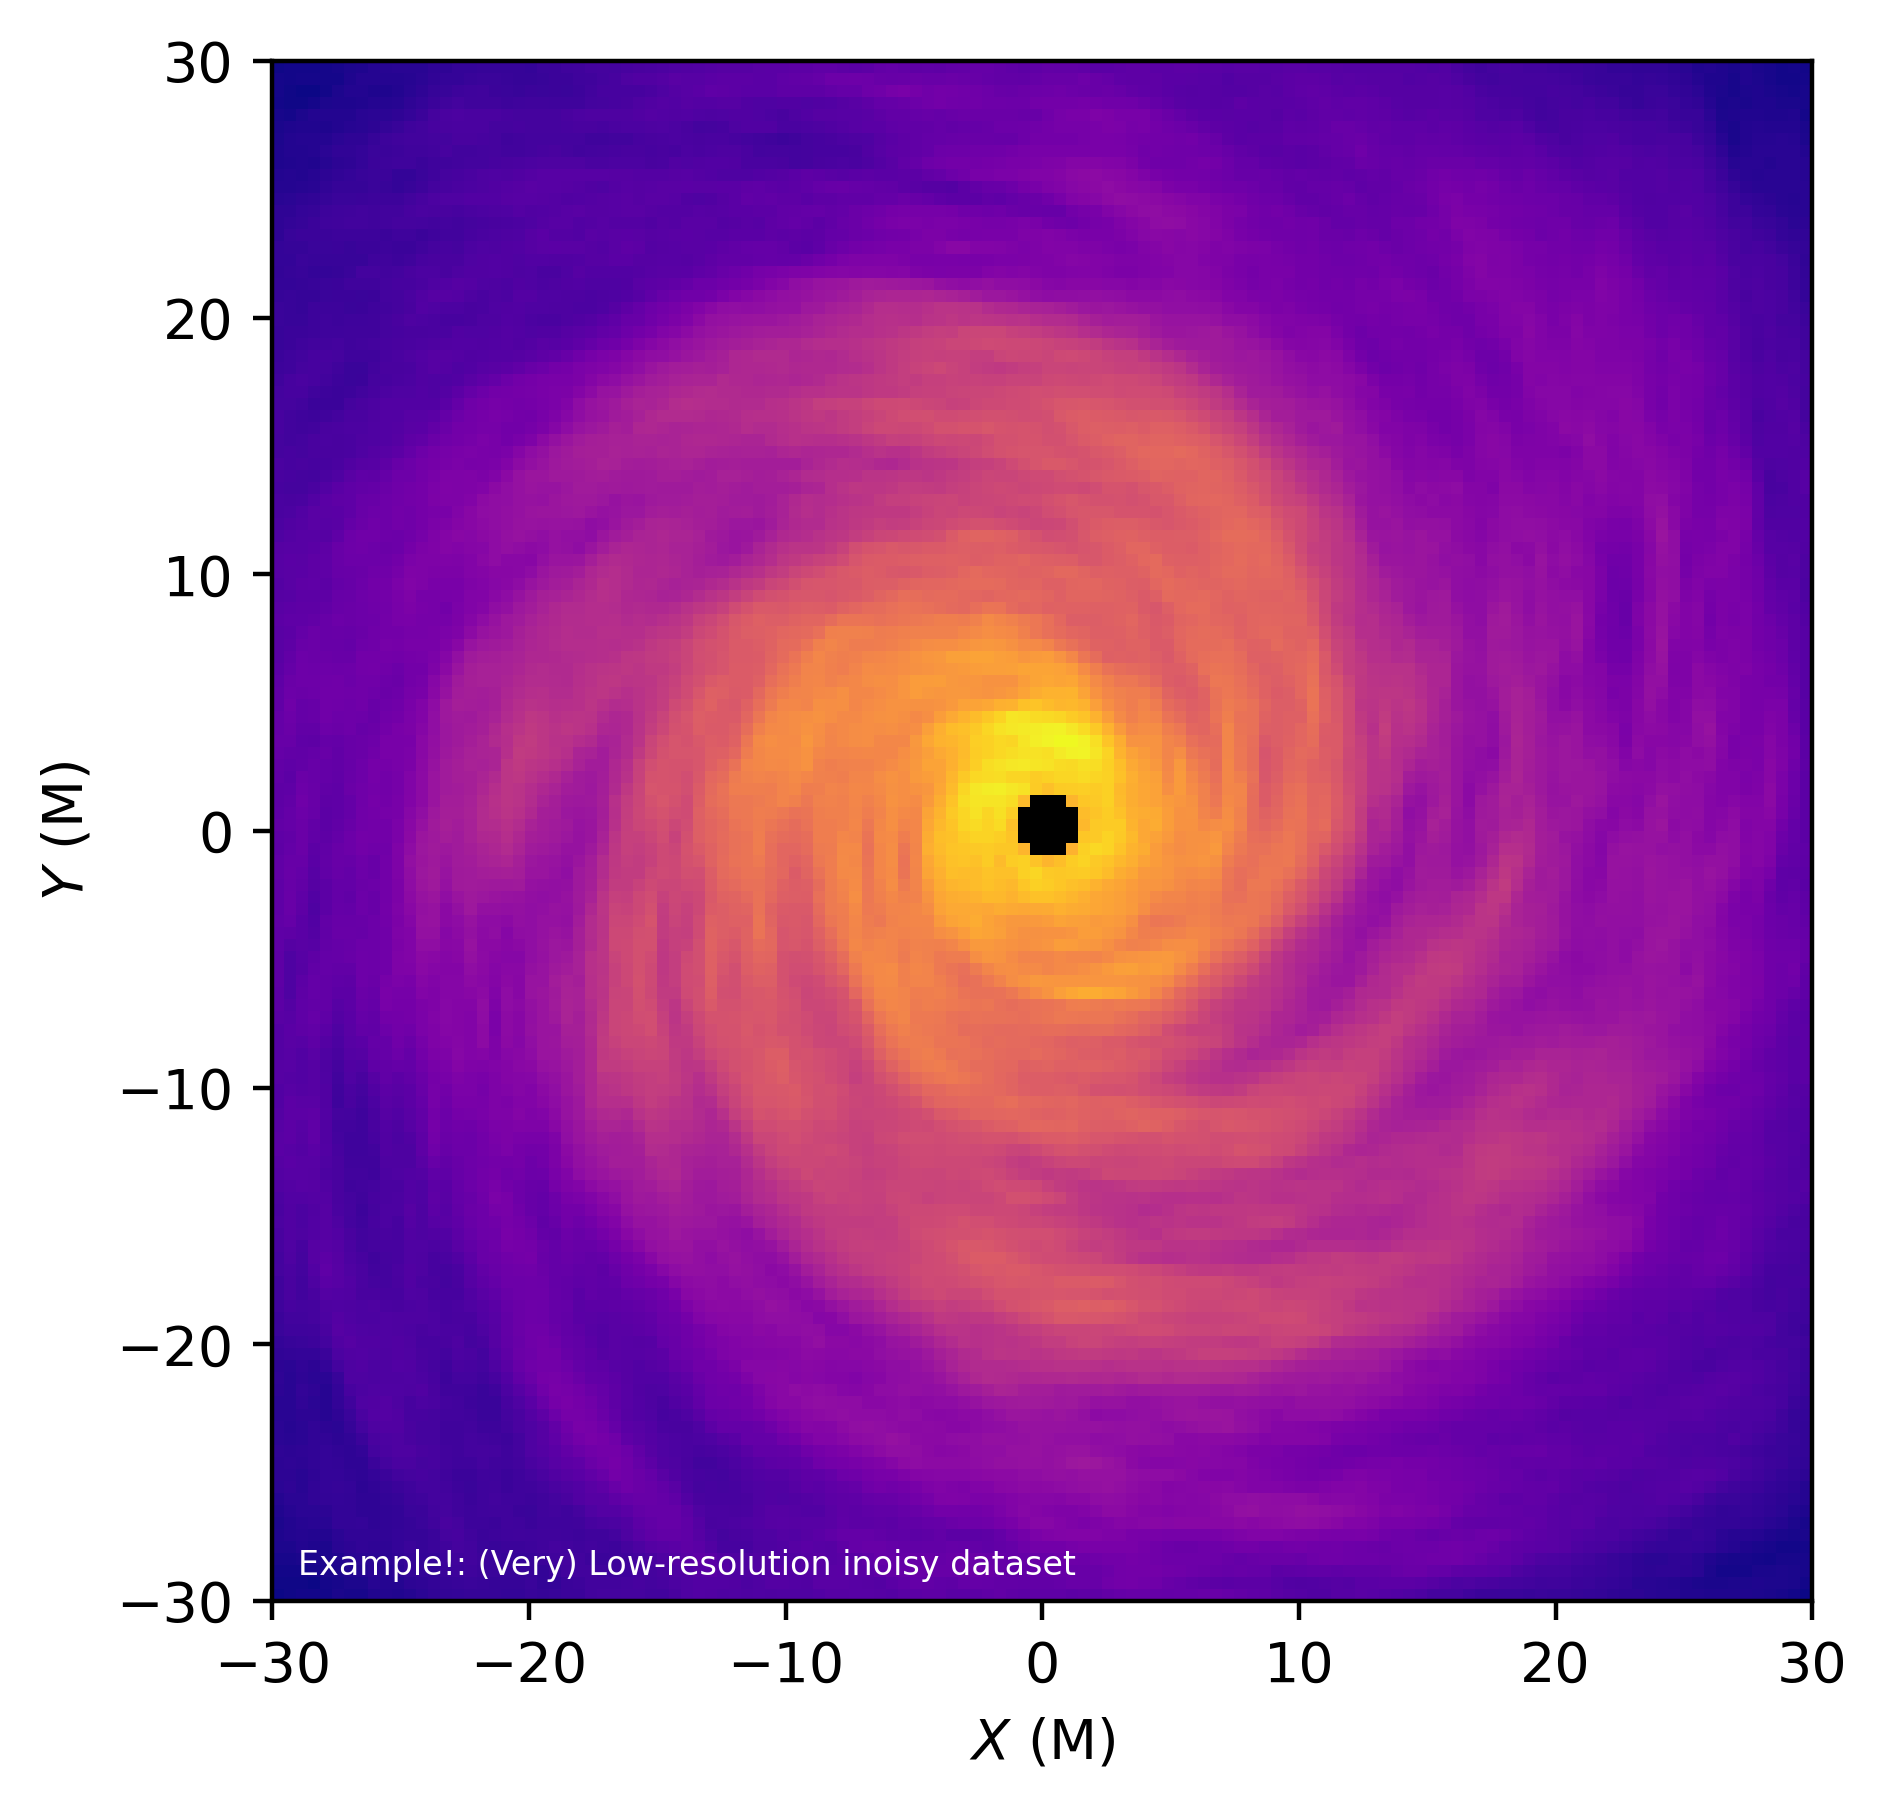

In [7]:
fig, ax = plt.subplots(figsize=[5,5],dpi=400)

#You can select different snapshots by changing the slicing 
ax.imshow(np.log(data_inoisy[55,:,:]),cmap="plasma",origin="lower",extent=[-30,30,-30,30])

ax.set_facecolor('xkcd:black')
ax.set_xlabel(r"$X$"+" "+"(M)")
ax.set_ylabel(r"$Y$"+" "+"(M)")
ax.text(-29,-29,"Example!: (Very) Low-resolution inoisy dataset",color="w",fontsize=6)

#plt.savefig(f'InoisySnapshot.png',dpi=400,bbox_inches='tight')
plt.show()

In [8]:
nt = data_inoisy.shape[0] #inoisy time resolution
ni = data_inoisy.shape[1] #inoisy x resolution
nj = data_inoisy.shape[2] #inoisy y resolution

try: 
	xtstart = np.array(hf['params/x0start'])[0]
	xtend = np.array(hf['params/x0end'])[0]

	x1start = np.array(hf['params/x1start'])[0]
	x2start = np.array(hf['params/x2start'])[0]

	x1end = np.array(hf['params/x1end'])[0]
	x2end = np.array(hf['params/x2end'])[0]

except:
	xtstart = np.array(hf['params/x0start'])
	xtend = np.array(hf['params/x0end'])

	x1start = np.array(hf['params/x1start'])
	x2start = np.array(hf['params/x2start'])

	x1end = np.array(hf['params/x1end'])
	x2end = np.array(hf['params/x2end'])


x1 = np.linspace(x1start, x1end, ni) 
x2 = np.linspace(x2start, x2end, nj)

times = np.linspace(xtstart, xtend, nt) #times of each frame of inoisy

h5py.File.close(hf)

AART operates on a dense grid over the `inoisy` source in order to generate images at any desired time. To achieve this, an interpolator is constructed over the source data, allowing the emission profile to be sampled continuously at any intermediate time between simulation frames.

Additionally, the emission time used in the ray tracing is a renormalized source time $\tilde{t}_s^{(n)}$, which accounts for the variable light travel time across the image plane and ensures consistent image generation across all photon half-orbit layers.

In [9]:
fact=-(D_obs+2*np.log(D_obs))

t0-=fact
t1-=fact
t2-=fact

i_dt = xtend/nt
timeconversion=i_dt*MMkg*Gc/cc**3/(3600*24) # [days]

interpolated3_R=RegularGridInterpolator((times,x1,x2),data_inoisy,fill_value=0,bounds_error=False,method='linear')

## Brisk-light prescription

Brisk light uses a modal highest-density interval (HDI) defined over the renormalized emission time $\tilde{t}_s^{(n)}$ of each lensing band. The HDI is constructed by identifying the connected interval around the mode of the band's emission-time distribution that encloses a chosen probability mass $p$. The slow-light emission time is then clipped to this interval: pixels whose emission times fall inside it are left unchanged, while those in the tails are mapped to the nearest boundary.

The parameter $p$ controls the amount of temporal information retained: when $p = 1$, brisk light recovers the full slow-light calculation, and when $p = 0$, each lensing band is evaluated at a single representative time — its modal emission time — rather than a single global snapshot as in fast light. This means that even at $p = 0$, brisk light preserves the leading temporal offset between the direct and indirect images, which fast light erases entirely.

In [10]:
#This is quite slow... 
p_b = 0.5 #probability mass

#modal_hdi_kde() gives us all the statistical parameters to clip the time interval
res0 = obsint.modal_hdi_kde(t0, p_b,trim_quantiles=(0.005, 0.995))
res1 = obsint.modal_hdi_kde(t1, p_b,trim_quantiles=(0.05,0.995))
res2 = obsint.modal_hdi_kde(t2, p_b,trim_quantiles=(0.05,0.995))


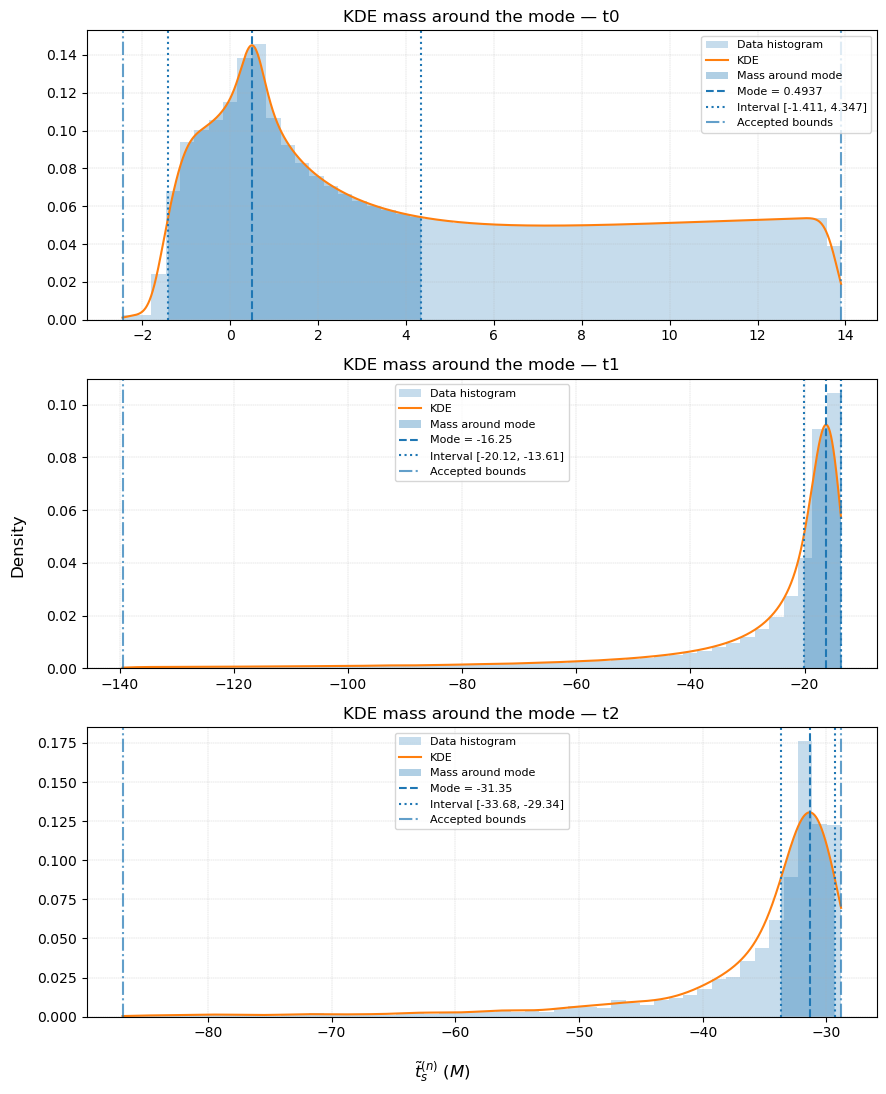

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(9, 11))

datasets  = [t0,  t1,  t2]
results   = [res0, res1, res2]
row_labels = ["t0", "t1", "t2"]

for ax, data, res, label in zip(axes, datasets, results, row_labels):

    data = np.asarray(data)
    data = data[np.isfinite(data)]

    x_grid  = res["x_grid"]
    density = res["density"]
    mask    = res["mask"]

    # --- histogram (clipped to accepted support when available) ---
    plot_data = data.copy()
    if "bounds" in res:
        lo, hi = res["bounds"]
        plot_data = plot_data[(plot_data >= lo) & (plot_data <= hi)]

    ax.hist(plot_data, bins=50, density=True, alpha=0.25, label="Data histogram")

    # --- KDE curve and shaded modal mass ---
    ax.plot(x_grid, density, label="KDE")
    ax.fill_between(x_grid, density, where=mask, alpha=0.35, label="Mass around mode")

    # --- mode ---
    ax.axvline(
        res["mode"],
        linestyle="--",
        label=f"Mode = {res['mode']:.4g}"
    )

    # --- HDI interval ---
    left, right = res["interval"]
    ax.axvline(left,  linestyle=":", label=f"Interval [{left:.4g}, {right:.4g}]")
    ax.axvline(right, linestyle=":")

    # --- accepted bounds ---
    if "bounds" in res:
        blo, bhi = res["bounds"]
        ax.axvline(blo, linestyle="-.", alpha=0.7, label="Accepted bounds")
        ax.axvline(bhi, linestyle="-.", alpha=0.7)

    ax.set_title(f"KDE mass around the mode — {label}")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)
    
fig.supxlabel(r'$\tilde{t}_s^{(n)}$ ($M$)')
fig.supylabel("Density")
plt.tight_layout()
plt.show()

In [12]:
#To cut the time interval, it is only necessary to know the left and right limits of the HDI
left0, right0 = res0["interval"]
ts_reduced0 = obsint.clip_ts_to_interval(t0, left0, right0)

left1, right1 = res1["interval"]
ts_reduced1 = obsint.clip_ts_to_interval(t1, left1, right1)

left2, right2 = res2["interval"]
ts_reduced2 = obsint.clip_ts_to_interval(t2, left2, right2)

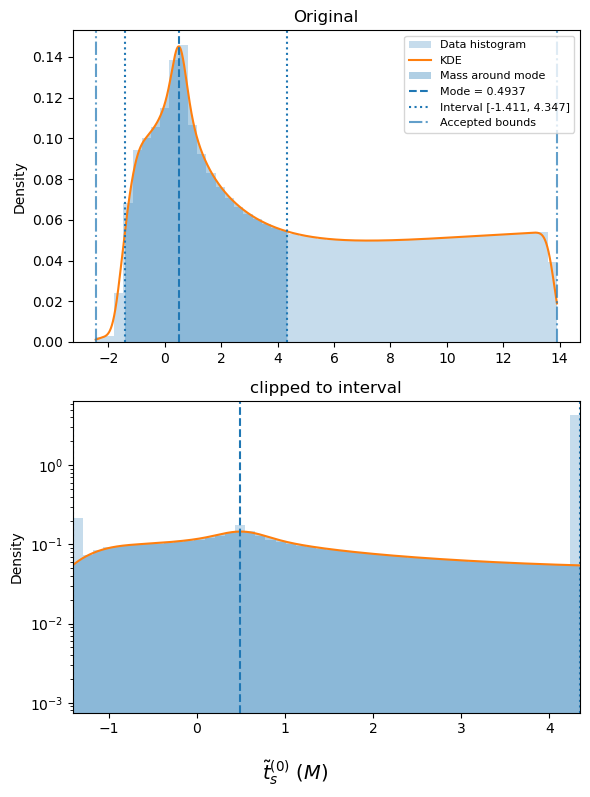

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(6, 8))

# --- left: original t0 ---
ax = axes[0]
data = np.asarray(t0)
data = data[np.isfinite(data)]

x_grid  = res0["x_grid"]
density = res0["density"]
mask    = res0["mask"]

plot_data = data.copy()
if "bounds" in res0:
    lo, hi = res0["bounds"]
    plot_data = plot_data[(plot_data >= lo) & (plot_data <= hi)]

ax.hist(plot_data, bins=50, density=True, alpha=0.25, label="Data histogram")
ax.plot(x_grid, density, label="KDE")
ax.fill_between(x_grid, density, where=mask, alpha=0.35, label="Mass around mode")
ax.axvline(res0["mode"], linestyle="--", label=f"Mode = {res0['mode']:.4g}")
left, right = res0["interval"]
ax.axvline(left,  linestyle=":", label=f"Interval [{left:.4g}, {right:.4g}]")
ax.axvline(right, linestyle=":")
if "bounds" in res0:
    blo, bhi = res0["bounds"]
    ax.axvline(blo, linestyle="-.", alpha=0.7, label="Accepted bounds")
    ax.axvline(bhi, linestyle="-.", alpha=0.7)

ax.set_ylabel("Density")
ax.set_title("Original")
ax.legend(fontsize=8)

# --- right: clipped t0 ---
ax = axes[1]
left, right = res0["interval"]


data = np.asarray(ts_reduced0)
data = data[np.isfinite(data)]

x_grid  = res0["x_grid"]
density = res0["density"]
mask    = res0["mask"]

ax.hist(data, bins=50, density=True, alpha=0.25, label="Data histogram")
ax.plot(x_grid, density, label="KDE")
ax.fill_between(x_grid, density, where=mask, alpha=0.35, label="Mass around mode")
ax.axvline(res0["mode"], linestyle="--", label=f"Mode = {res0['mode']:.4g}")
ax.axvline(left,  linestyle=":", label=f"Interval [{left:.4g}, {right:.4g}]")
ax.axvline(right, linestyle=":")

ax.set_xlim(left,right)
ax.set_ylabel("Density")
ax.set_title("clipped to interval")
ax.set_yscale("log")

fig.supxlabel(r'$\tilde{t}_s^{(0)}$ ($M$)', fontsize=14)
plt.tight_layout()
plt.show()

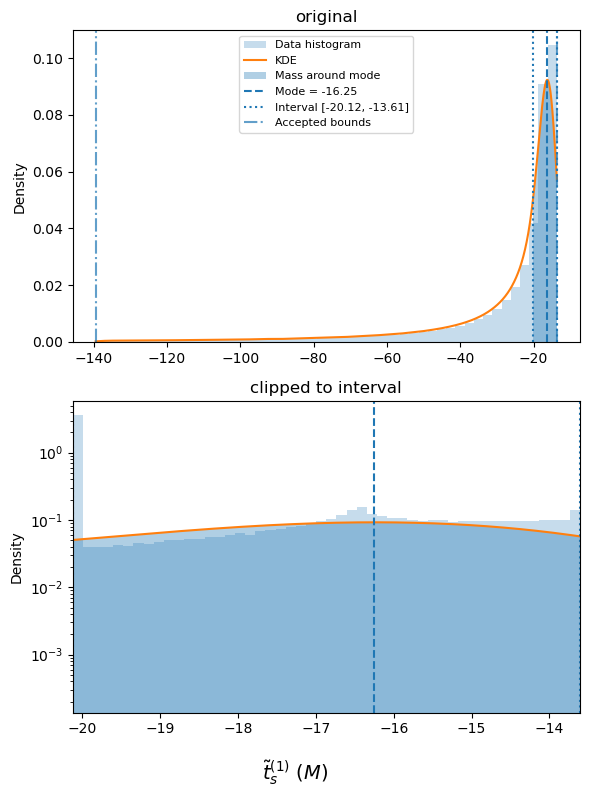

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(6, 8))

# --- left: original t1 ---
ax = axes[0]
data = np.asarray(t1)
data = data[np.isfinite(data)]

x_grid  = res1["x_grid"]
density = res1["density"]
mask    = res1["mask"]

plot_data = data.copy()
if "bounds" in res1:
    lo, hi = res1["bounds"]
    plot_data = plot_data[(plot_data >= lo) & (plot_data <= hi)]

ax.hist(plot_data, bins=50, density=True, alpha=0.25, label="Data histogram")
ax.plot(x_grid, density, label="KDE")
ax.fill_between(x_grid, density, where=mask, alpha=0.35, label="Mass around mode")
ax.axvline(res1["mode"], linestyle="--", label=f"Mode = {res1['mode']:.4g}")
left, right = res1["interval"]
ax.axvline(left,  linestyle=":", label=f"Interval [{left:.4g}, {right:.4g}]")
ax.axvline(right, linestyle=":")
if "bounds" in res1:
    blo, bhi = res1["bounds"]
    ax.axvline(blo, linestyle="-.", alpha=0.7, label="Accepted bounds")
    ax.axvline(bhi, linestyle="-.", alpha=0.7)

ax.set_ylabel("Density")
ax.set_title("original")
ax.legend(fontsize=8)

# --- right: clipped t1 ---
ax = axes[1]
left, right = res1["interval"]

data = np.asarray(ts_reduced1)
data = data[np.isfinite(data)]

x_grid  = res1["x_grid"]
density = res1["density"]
mask    = res1["mask"]

ax.hist(data, bins=50, density=True, alpha=0.25, label="Data histogram")
ax.plot(x_grid, density, label="KDE")
ax.fill_between(x_grid, density, where=mask, alpha=0.35, label="Mass around mode")
ax.axvline(res1["mode"], linestyle="--", label=f"Mode = {res1['mode']:.4g}")
ax.axvline(left,  linestyle=":", label=f"Interval [{left:.4g}, {right:.4g}]")
ax.axvline(right, linestyle=":")

ax.set_xlim(left,right)
ax.set_ylabel("Density")
ax.set_title("clipped to interval")
ax.set_yscale("log")


fig.supxlabel(r'$\tilde{t}_s^{(1)}$ ($M$)', fontsize=14)
plt.tight_layout()
plt.show()

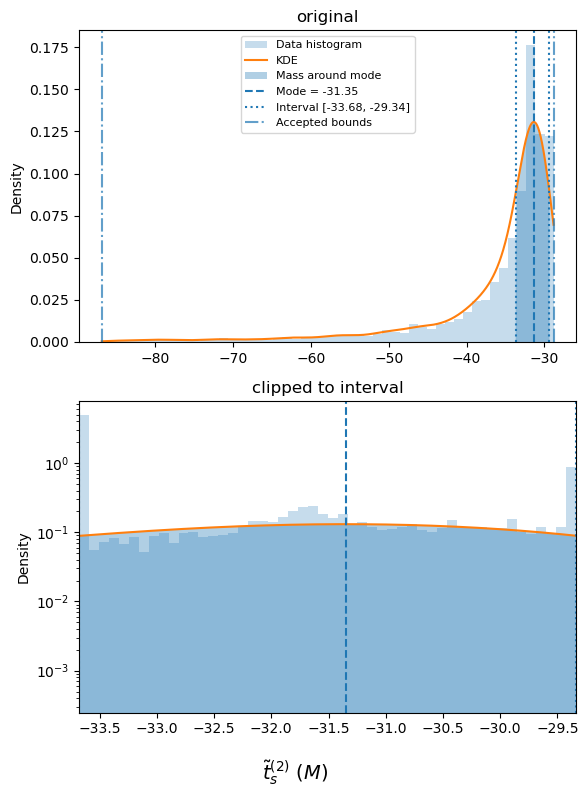

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(6, 8))

# --- top: original t2 ---
ax = axes[0]
data = np.asarray(t2)
data = data[np.isfinite(data)]

x_grid  = res2["x_grid"]
density = res2["density"]
mask    = res2["mask"]

plot_data = data.copy()
if "bounds" in res2:
    lo, hi = res2["bounds"]
    plot_data = plot_data[(plot_data >= lo) & (plot_data <= hi)]

ax.hist(plot_data, bins=50, density=True, alpha=0.25, label="Data histogram")
ax.plot(x_grid, density, label="KDE")
ax.fill_between(x_grid, density, where=mask, alpha=0.35, label="Mass around mode")
ax.axvline(res2["mode"], linestyle="--", label=f"Mode = {res2['mode']:.4g}")
left, right = res2["interval"]
ax.axvline(left,  linestyle=":", label=f"Interval [{left:.4g}, {right:.4g}]")
ax.axvline(right, linestyle=":")
if "bounds" in res2:
    blo, bhi = res2["bounds"]
    ax.axvline(blo, linestyle="-.", alpha=0.7, label="Accepted bounds")
    ax.axvline(bhi, linestyle="-.", alpha=0.7)

ax.set_ylabel("Density")
ax.set_title("original")
ax.legend(fontsize=8)

# --- bottom: clipped t2 ---
ax = axes[1]
left, right = res2["interval"]

data = np.asarray(ts_reduced2)
data = data[np.isfinite(data)]

x_grid  = res2["x_grid"]
density = res2["density"]
mask    = res2["mask"]

ax.hist(data, bins=50, density=True, alpha=0.25, label="Data histogram")
ax.plot(x_grid, density, label="KDE")
ax.fill_between(x_grid, density, where=mask, alpha=0.35, label="Mass around mode")
ax.axvline(res2["mode"], linestyle="--", label=f"Mode = {res2['mode']:.4g}")
ax.axvline(left,  linestyle=":", label=f"Interval [{left:.4g}, {right:.4g}]")
ax.axvline(right, linestyle=":")
ax.set_xlim(left, right)
ax.set_ylabel("Density")
ax.set_title("clipped to interval")
ax.set_yscale("log")

fig.supxlabel(r'$\tilde{t}_s^{(2)}$ ($M$)', fontsize=14)
plt.tight_layout()
plt.show()

## Image generation under different light prescriptions

From a single `inoisy` snapshot, AART can produce images under three different light-propagation prescriptions:

- **Slow-light**: the physically accurate prescription, where each pixel in the image is sampled at the source time corresponding to its individual geodesic travel time $\tilde{t}_s^{(n)}(\alpha, \beta)$.
- **Fast-light**: a common approximation where all pixels in a snapshot are evaluated at a single global source emission time.
- **Brisk-light**: an intermediate prescription introduced in Rojas-Paternina & Cárdenas-Avendaño (2025), which retains the dominant temporal structure of each lensing band by clipping the slow-light emission times to a modal HDI, reducing the required temporal support while preserving the leading delay ordering between direct and indirect images.

Since `inoisy` generates a source movie with periodic temporal boundary conditions, the emission times returned by the ray tracer must be mapped into the periodic domain of the source before interpolation.

In [16]:
#The observer time of the snapshot can be changed by modifying the index in the slicing below
tsnap = times[55]

#times used in broadcast modes
ts0 = np.mod(t0 + tsnap, xtend)
ts1 = np.mod(t1 + tsnap, xtend)
ts2 = np.mod(t2 + tsnap, xtend)

#left and right values for brisk
left0_snap  = np.mod(left0 + tsnap, xtend)
right0_snap = np.mod(right0 + tsnap, xtend)

left1_snap  = np.mod(left1 + tsnap, xtend)
right1_snap = np.mod(right1 + tsnap, xtend)

left2_snap  = np.mod(left2 + tsnap, xtend)
right2_snap = np.mod(right2 + tsnap, xtend)

The functions used to compute the images under each prescription are implemented in `aart_func/intensity_f.py`, where the detailed construction of each light-propagation mode can be inspected.

In [17]:
#Slow light generation
i_bghts0 = obsint.slow_light(supergrid0,mask0,sign0,spin_case,isco,rs0,phi0,ts0, interpolated3_R,thetao)
i_bghts1 = obsint.slow_light(supergrid1,mask1,sign1,spin_case,isco,rs1,phi1,ts1, interpolated3_R,thetao)
i_bghts2 = obsint.slow_light(supergrid2,mask2,sign2,spin_case,isco,rs2,phi2,ts2, interpolated3_R,thetao)

I0_slow = (i_bghts0).reshape(N0,N0).T
I1_slow = (i_bghts1).reshape(N1,N1).T
I2_slow = (i_bghts2).reshape(N2,N2).T

In [18]:
#Brisk light generation
i_bghts0 = obsint.brisk_light(supergrid0, mask0, sign0, spin_case, isco, rs0, phi0, ts0,interpolated3_R, thetao, left0_snap, right0_snap)
i_bghts1 = obsint.brisk_light(supergrid1, mask1, sign1, spin_case, isco, rs1, phi1, ts1,interpolated3_R, thetao, left1_snap, right1_snap)
i_bghts2 = obsint.brisk_light(supergrid2, mask2, sign2, spin_case, isco, rs2, phi2, ts2,interpolated3_R, thetao, left2_snap, right2_snap)

I0_brisk = (i_bghts0).reshape(N0,N0).T
I1_brisk = (i_bghts1).reshape(N1,N1).T
I2_brisk = (i_bghts2).reshape(N2,N2).T

In [19]:
#Fast light generation
i_bghts0 = obsint.fast_light(supergrid0, mask0, sign0, spin_case, isco,rs0, phi0, tsnap, interpolated3_R, thetao)
i_bghts1 = obsint.fast_light(supergrid1, mask1, sign1, spin_case, isco,rs1, phi1, tsnap, interpolated3_R, thetao)
i_bghts2 = obsint.fast_light(supergrid2, mask2, sign2, spin_case, isco,rs2, phi2, tsnap, interpolated3_R, thetao)

I0_fast = i_bghts0.reshape(N0, N0).T
I1_fast = i_bghts1.reshape(N1, N1).T
I2_fast = i_bghts2.reshape(N2, N2).T

In [20]:
#Total Images
I_slow = I0_slow+I1_slow+I2_slow
I_brisk = I0_brisk+I1_brisk+I2_brisk
I_fast = I0_fast+I1_fast+I2_fast

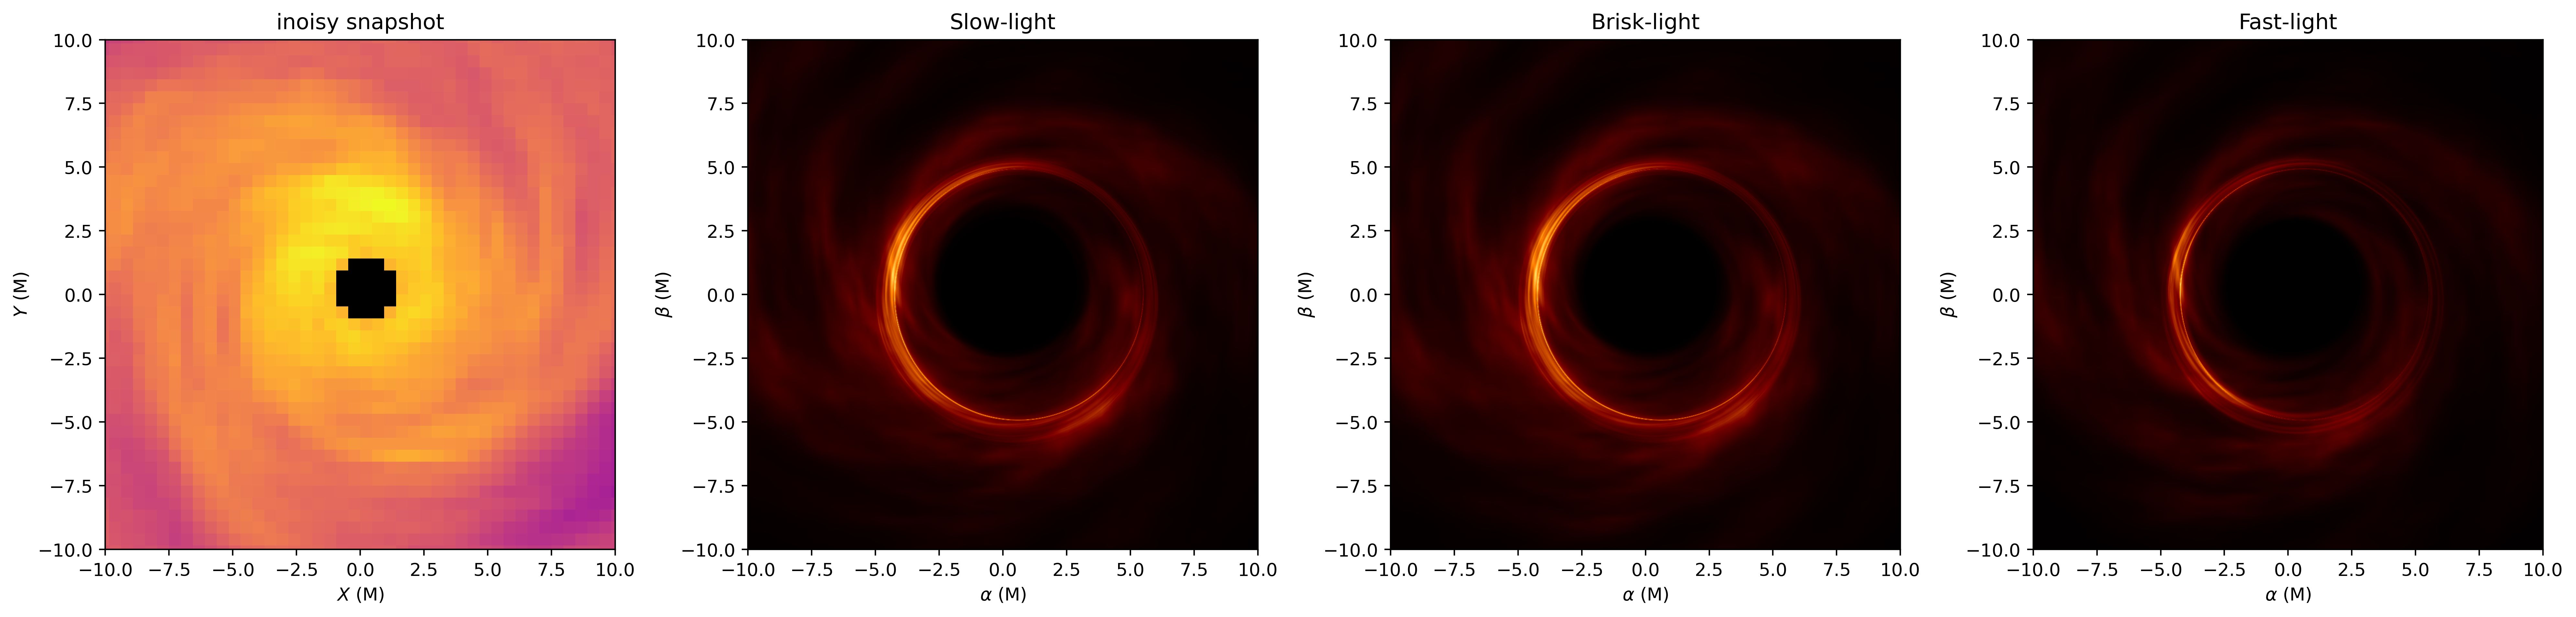

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi=400)

#col 0: noisy snapshot 
ax = axes[0]
ax.imshow(np.log(data_inoisy[55, :, :]), cmap="plasma", origin="lower", extent=[-30, 30, -30, 30])
ax.set_facecolor('xkcd:black')
ax.set_xlabel(r"$X$ (M)")
ax.set_ylabel(r"$Y$ (M)")
ax.set_title("inoisy snapshot")
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)

#col 1: slow
ax = axes[1]
ax.imshow(I_slow, vmax=np.max(I_slow) * 1.2, origin="lower", cmap="afmhot", extent=[-lim0, lim0, -lim0, lim0])
ax.set_xlabel(r"$\alpha$ (M)")
ax.set_ylabel(r"$\beta$ (M)")
ax.set_title("Slow-light")
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)

#col 2: brisk 
ax = axes[2]
ax.imshow(I_brisk, vmax=np.max(I_brisk) * 1.2, origin="lower", cmap="afmhot", extent=[-lim0, lim0, -lim0, lim0])
ax.set_xlabel(r"$\alpha$ (M)")
ax.set_ylabel(r"$\beta$ (M)")
ax.set_title("Brisk-light")
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)

#col 3: fast 
ax = axes[3]
ax.imshow(I_fast, vmax=np.max(I_fast) * 1.2, origin="lower", cmap="afmhot", extent=[-lim0, lim0, -lim0, lim0])
ax.set_xlabel(r"$\alpha$ (M)")
ax.set_ylabel(r"$\beta$ (M)")
ax.set_title("Fast-light")
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)

plt.tight_layout()
plt.show()

## Movie generation

Movies under all three prescriptions can be produced using the scripts listed below. All simulation parameters — including the used source, the spatial and temporal resolution of the movie, and the parameters of the physical emission envelope — are controlled through `params.py`.

In [22]:
#Slow-light movie generation
%time !python iMovies.py


Thanks for using AART
Movies
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Reading file:  ./Results/Rays_a_0.94_i_17.h5
Reading inoisy file:  inoisy.h5
AART starts!
Calculating an image at time t=1.09091 (M)
Calculating an image at time t=3.27273 (M)
Calculating an image at time t=0.0 (M)
Calculating an image at time t=2.18182 (M)
Calculating an image at time t=4.36364 (M)
Calculating an image at time t=5.45455 (M)
Calculating an image at time t=6.54545 (M)
Calculating an image at time t=7.63636 (M)
Calculating an image at time t=8.72727 (M)
Calculating an image at time t=9.81818 (M)
Calculating an image at time t=10.90909 (M)
Calculating an image at time t=12.0 (M)
Images  ./Results/Images_a_0.94_i_17_inoisy.h5  created.

CPU times: user 60.8 ms, sys: 44.8 ms, total: 106 ms
Wall time: 9.11 s


In [23]:
#Brisk-light movie generation
%time !python BriskLightMovie.py


Thanks for using AART
Brisk Movies
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Reading file:  ./Results/Rays_a_0.94_i_17.h5
Reading inoisy file:  inoisy.h5
Brisk-Light calculation starts!

Thanks for using AART

Thanks for using AART

Thanks for using AART

Thanks for using AART
Brisk Movies
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Brisk Movies
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Brisk Movies
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Brisk Movies
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Reading file:  ./Results/Rays_a_0.94_i_17.h5
Reading file:  ./Results/Rays_a_0.94_i_17.h5
Reading file:  ./Results/Rays_a_0.94_i_17.h5
Reading file:  ./Results/Rays_a_0.94_i_17.h5
Reading inoisy file:  inoisy.h5
Reading inoisy file:  inoisy.h5
Reading inoisy file:  inoisy.h5
Reading inoisy file:  inoisy.h5
Brisk-Light calculation starts!
Brisk-Light calculation starts!
Brisk-Light calculation starts!
Brisk-Light calculation starts!
Calculatin

In [24]:
#Fast-light movie generation
%time !python FastLightMovie.py


Thanks for using AART
Computing the fast-light Movie
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Reading file:  ./Results/Rays_a_0.94_i_17.h5
Reading inoisy file:  inoisy.h5
Fast-Light calculation starts!

Thanks for using AART

Thanks for using AART

Thanks for using AART

Thanks for using AART
Computing the fast-light Movie
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Computing the fast-light Movie
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Computing the fast-light Movie
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Computing the fast-light Movie
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Reading file:  ./Results/Rays_a_0.94_i_17.h5
Reading file:  ./Results/Rays_a_0.94_i_17.h5
Reading file:  ./Results/Rays_a_0.94_i_17.h5
Reading file:  ./Results/Rays_a_0.94_i_17.h5
Reading inoisy file:  inoisy.h5
Reading inoisy file:  inoisy.h5
Fast-Light calculation starts!
Fast-Light calculation starts!
Reading inoisy file:  inoisy.h5
Reading inoisy file

In [25]:
%time !python PrescriptionComparison.py


Thanks for using AART
Reading file:  ./Results/LensingBands_a_0.94_i_17.h5
Reading file:  ./Results/Rays_a_0.94_i_17.h5
Reading file:  ./Results/Images_a_0.94_i_17_inoisy.h5
Reading file:  ./Results/BriskLight_p0.0_a_0.94_i_17_inoisy.h5
Reading file:  ./Results/FastLight_Images_a_0.94_i_17_inoisy.h5
Starting Picture comparation
The images was created - Snapshot t=1
   Dimension: (2500, 2500)
NMSE Calculating...
   Slow vs Fast:  4.639e-01
   Slow vs Brisk: 4.743e-01
   Fast vs Brisk: 2.751e-02

 Picture created in : ./Results/Comparison_triplets_tsnap_0001_p0.0_i17.png
CPU times: user 54.7 ms, sys: 32.3 ms, total: 87 ms
Wall time: 9.37 s


![Alt text](Comparison.png)

# Thanks for using AART!
## License
MIT license

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.